<a href="https://colab.research.google.com/github/anushakota44/Anusha-kota/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
   pclass survived                                             name     sex  \
0       1        1                    Allen, Miss. Elisabeth Walton  female   
1       1        1                   Allison, Master. Hudson Trevor    male   
2       1        0                     Allison, Miss. Helen Loraine  female   
3       1        0             Allison, Mr. Hudson Joshua Creighton    male   
4       1        0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                

/tmp/ipykernel_1961/965966785.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age'] = imputer.fit_transform(df[['age']])
/tmp/ipykernel_1961/965966785.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex'] = encoder.fit_transform(df['sex'])



Accuracy: 0.8206106870229007

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       144
           1       0.87      0.71      0.78       118

    accuracy                           0.82       262
   macro avg       0.83      0.81      0.81       262
weighted avg       0.83      0.82      0.82       262


Confusion Matrix:

[[131  13]
 [ 34  84]]


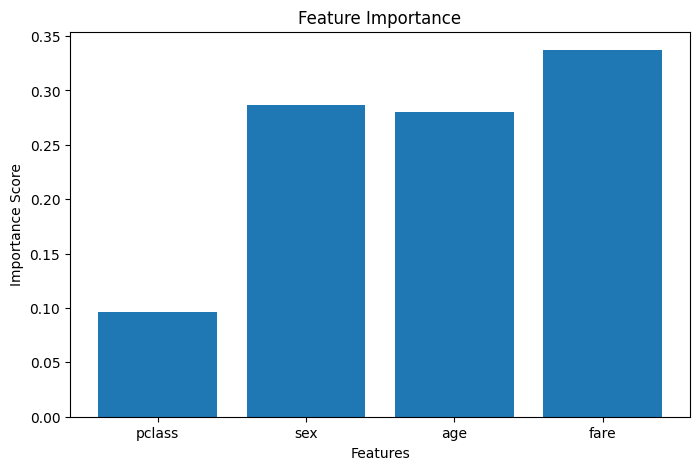


Custom Prediction:
Passenger Did Not Survive


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [1]:
# =========================================================
# MACHINE LEARNING PROJECT
# TITANIC SURVIVAL PREDICTION
# =========================================================

# ---------------------------------------------------------
# STEP 1: IMPORT LIBRARIES
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------------------------------------------------------
# STEP 2: LOAD DATASET
# ---------------------------------------------------------

titanic = fetch_openml(name='titanic', version=1, as_frame=True)

df = titanic.frame

print("First 5 Rows:")
print(df.head())

# ---------------------------------------------------------
# STEP 3: SELECT IMPORTANT COLUMNS
# ---------------------------------------------------------

df = df[['pclass', 'sex', 'age', 'fare', 'survived']]

print("\nDataset Info:")
print(df.info())

# ---------------------------------------------------------
# STEP 4: HANDLE MISSING VALUES
# ---------------------------------------------------------

imputer = SimpleImputer(strategy='mean')

df['age'] = imputer.fit_transform(df[['age']])

# ---------------------------------------------------------
# STEP 5: ENCODE CATEGORICAL DATA
# ---------------------------------------------------------

encoder = LabelEncoder()

df['sex'] = encoder.fit_transform(df['sex'])

# male = 1
# female = 0

# ---------------------------------------------------------
# STEP 6: DEFINE FEATURES AND TARGET
# ---------------------------------------------------------

X = df[['pclass', 'sex', 'age', 'fare']]
y = df['survived']

# ---------------------------------------------------------
# STEP 7: SPLIT TRAINING AND TESTING DATA
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------------
# STEP 8: TRAIN MACHINE LEARNING MODEL
# ---------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ---------------------------------------------------------
# STEP 9: MAKE PREDICTIONS
# ---------------------------------------------------------

y_pred = model.predict(X_test)

# ---------------------------------------------------------
# STEP 10: EVALUATE MODEL
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# ---------------------------------------------------------
# STEP 11: FEATURE IMPORTANCE VISUALIZATION
# ---------------------------------------------------------

importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

# ---------------------------------------------------------
# STEP 12: PREDICT CUSTOM DATA
# ---------------------------------------------------------

# Example:
# pclass = 1
# sex = female = 0
# age = 25
# fare = 100

sample_data = [[1, 0, 25, 100]]

prediction = model.predict(sample_data)

print("\nCustom Prediction:")

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")